# Comparing KAN-AD Function Families on SWaT

This notebook compares three hybrid models (KANAD + Deepsvdd) with differnet  KAN-AD variants on the **SWaT multivariate time-series dataset**:

- **Fourier KAN-AD** (official KAN-AD family)
- **Wavelet KAN-AD**
- **FastKAN-AD (RBF)**

The purpose is to decide which KAN family to carry forward into the hybrid **KAN-AD + DeepSVDD** pipeline.

## Decision rule used here

For **multivariate time-series (MTS)** evaluation, the official KAN-AD paper reports **Best F1** in its MTS comparison table. Because SWaT is an MTS dataset, this notebook uses **Best F1 as the main selection metric** for the family comparison.

So even though Event F1, Delay F1, and AUPRC are still visualized, the final model choice is based on **Best F1** only.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame([
  {
    "Model": "Fourier KAN-AD",
    "Best F1": 0.9199784017278612,
    "Best F1 Precision": 0.9833321790521042,
    "Best F1 Recall": 0.864293975610251,
    "Event F1": 0.12244897959183623,
    "Event Precision": 0.125,
    "Event Recall": 0.12,
    "Delay F1": 0.29572532984371763,
    "Delay Precision": 0.17620066109274743,
    "Delay Recall": 0.9193839660734939,
    "AUPRC": 0.9456383793713747
  },
  {
    "Model": "Wavelet KAN-AD",
    "Best F1": 0.9062763697733286,
    "Best F1 Precision": 0.8680924597718236,
    "Best F1 Recall": 0.9479739463912505,
    "Event F1": 0.1999999999999997,
    "Event Precision": 0.5999999999999999,
    "Event Recall": 0.12,
    "Delay F1": 0.6850392449712409,
    "Delay Precision": 0.5629104487355241,
    "Delay Recall": 0.8748452813343344,
    "AUPRC": 0.9703678489616743
  },
  {
    "Model": "FastKAN-AD (RBF)",
    "Best F1": 0.9445027496746563,
    "Best F1 Precision": 0.9781961261711702,
    "Best F1 Recall": 0.9130531826390439,
    "Event F1": 0.08791208791208752,
    "Event Precision": 0.06060606060606061,
    "Event Recall": 0.16,
    "Delay F1": 0.32857728299815364,
    "Delay Precision": 0.20165302223411816,
    "Delay Recall": 0.8866546273562892,
    "AUPRC": 0.9308137032531792
  }
])
results

,Model,Best F1,Best F1 Precision,Best F1 Recall,Event F1,Event Precision,Event Recall,Delay F1,Delay Precision,Delay Recall,AUPRC
0,Fourier KAN-AD,0.919978,0.983332,0.864294,0.122449,0.125000,0.12,0.295725,0.176201,0.919384,0.945638
1,Wavelet KAN-AD,0.906276,0.868092,0.947974,0.200000,0.600000,0.12,0.685039,0.562910,0.874845,0.970368
2,FastKAN-AD (RBF),0.944503,0.978196,0.913053,0.087912,0.060606,0.16,0.328577,0.201653,0.886655,0.930814


## Metric overview

The notebook keeps the following metrics for context:

- **Best F1**: primary comparison metric for SWaT because SWaT is MTS
- **Event F1**: segment-level detection quality
- **Delay F1**: timeliness of detection
- **AUPRC**: ranking quality

The final choice will still be made using **Best F1**.


In [ ]:
summary_cols = ["Model", "Best F1", "Event F1", "Delay F1", "AUPRC"]
summary = results[summary_cols].copy()
summary = summary.sort_values("Best F1", ascending=False).reset_index(drop=True)
summary

,Model,Best F1,Event F1,Delay F1,AUPRC
0,FastKAN-AD (RBF),0.944503,0.087912,0.328577,0.930814
1,Fourier KAN-AD,0.919978,0.122449,0.295725,0.945638
2,Wavelet KAN-AD,0.906276,0.200000,0.685039,0.970368


In [ ]:
ranked = results.copy()
for metric in ["Best F1", "Event F1", "Delay F1", "AUPRC"]:
    ranked[f"Rank ({metric})"] = ranked[metric].rank(ascending=False, method="min").astype(int)

ranked = ranked.sort_values("Rank (Best F1)")
ranked[[
    "Model",
    "Best F1", "Rank (Best F1)",
    "Event F1", "Rank (Event F1)",
    "Delay F1", "Rank (Delay F1)",
    "AUPRC", "Rank (AUPRC)"
]]

,Model,Best F1,Rank (Best F1),Event F1,Rank (Event F1),Delay F1,Rank (Delay F1),AUPRC,Rank (AUPRC)
2,FastKAN-AD (RBF),0.944503,1,0.087912,3,0.328577,2,0.930814,3
0,Fourier KAN-AD,0.919978,2,0.122449,2,0.295725,3,0.945638,2
1,Wavelet KAN-AD,0.906276,3,0.200000,1,0.685039,1,0.970368,1


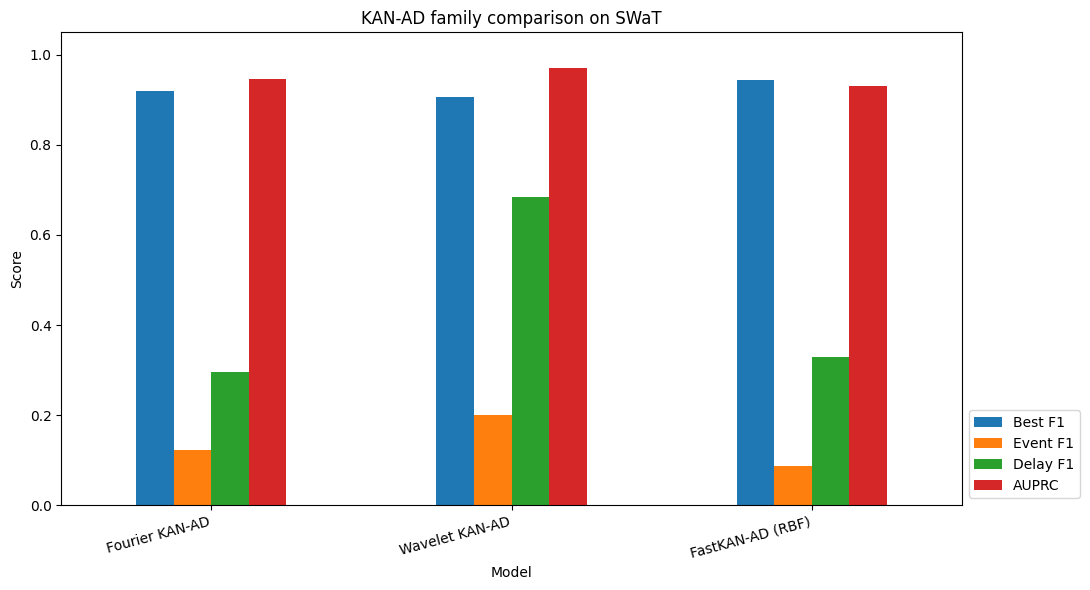

In [ ]:
metric_cols = ["Best F1", "Event F1", "Delay F1", "AUPRC"]
plot_df = results.set_index("Model")[metric_cols]

ax = plot_df.plot(kind="bar", figsize=(11, 6))
ax.set_title("KAN-AD family comparison on SWaT")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left", bbox_to_anchor=(1.0, 0.0))
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

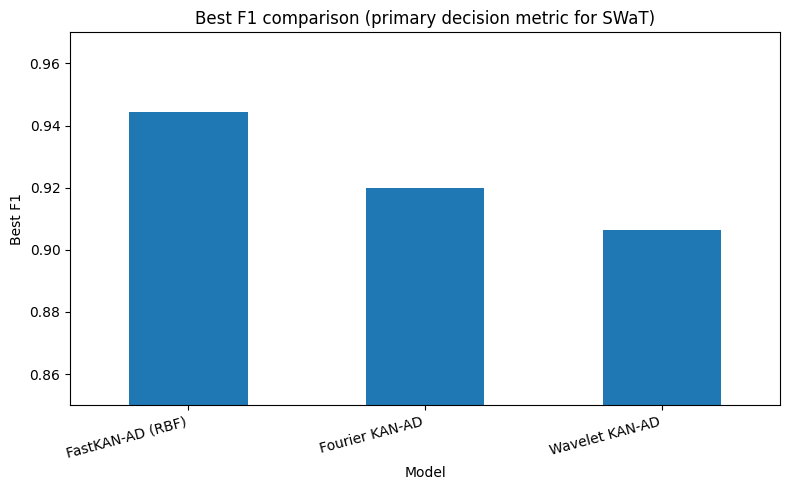

In [ ]:
bestf1 = results.sort_values("Best F1", ascending=False)[["Model", "Best F1"]].set_index("Model")
ax = bestf1.plot(kind="bar", figsize=(8, 5), legend=False)
ax.set_title("Best F1 comparison (primary decision metric for SWaT)")
ax.set_ylabel("Best F1")
ax.set_ylim(0.85, 0.97)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
pr = results[[
    "Model",
    "Best F1 Precision", "Best F1 Recall",
    "Event Precision", "Event Recall",
    "Delay Precision", "Delay Recall"
]].copy()
pr

,Model,Best F1 Precision,Best F1 Recall,Event Precision,Event Recall,Delay Precision,Delay Recall
0,Fourier KAN-AD,0.983332,0.864294,0.125000,0.12,0.176201,0.919384
1,Wavelet KAN-AD,0.868092,0.947974,0.600000,0.12,0.562910,0.874845
2,FastKAN-AD (RBF),0.978196,0.913053,0.060606,0.16,0.201653,0.886655


## Interpretation

### Best F1
- **FastKAN-AD (RBF)** is the best on the primary metric with **0.9445**
- **Fourier KAN-AD** comes next with **0.9200**
- **Wavelet KAN-AD** is third with **0.9063**

### Event F1
- **Wavelet KAN-AD** is strongest here (**0.2000**)
- Fourier is second
- FastKAN-AD is weakest on event-level continuity

### Delay F1
- **Wavelet KAN-AD** is clearly strongest (**0.6850**)
- FastKAN-AD and Fourier are much lower

### AUPRC
- **Wavelet KAN-AD** is strongest (**0.9704**)
- Fourier is second
- FastKAN-AD is third

## Why continue with FastKAN-AD anyway?

Because this comparison is for **SWaT**, which is **multivariate**, and the official KAN-AD paper uses **Best F1** for its MTS comparison. To stay consistent with that evaluation choice, the fairest selection criterion here is **Best F1**, not Event F1 or Delay F1.


In [ ]:
winner = results.loc[results["Best F1"].idxmax(), ["Model", "Best F1"]]
winner

,2
Model,FastKAN-AD (RBF)
Best F1,0.944503


## Final decision

Based on the official KAN-AD MTS evaluation convention and the results above, the selected family is:

# **FastKAN-AD (RBF)**

### Reason
It achieves the **highest Best F1** on SWaT, which is the main metric used for MTS comparison in the official paper.

### Practical consequence
The next hybrid notebook should therefore continue with:

- **FastKAN-AD (RBF)** as the KAN forecasting branch
- **DeepSVDD** as the latent distance branch

while keeping the rest of the hybrid pipeline unchanged.


In [ ]:
final_table = summary.copy()
final_table.to_csv("kanad_family_comparison_swat.csv", index=False)
print("Saved comparison table to kanad_family_comparison_swat.csv")

Saved comparison table to kanad_family_comparison_swat.csv
